# Welcome to Big Data!!!

## Today we are going to analyze Rainfall data from central Park to get you started

### We are going to do this all in a Jupyter notebook which was formerly called iPython.  This will take some getting used to. You actually do your programming in a window in a web browser or in a program.  Today we will use googles version but next class we will install our own

Ok, Lets get you started.  But make sure you read the syllabus and get a binder to keep the handouts.  You need to do the code.org also!

Today we are going to use colab on your google workspace.  
- Go to your google drive
- where it says new google doc or sheet go to more and choose Colaboratory
- This is going to open a new python notebook that looks similar to this
- you type your commands in the window and then press play or shift-enter

Today we are going to look at daily precipitation data from Central Park. 
What questions could we ask and answer?  I have downloaded the data from 1876 onward!  
- The precipiation in the month I was born.
- The annual average precipiation in Central Park
- Has precipitation changed over time?
- Does any month typically get more precipitation in NYC?

Type in what you see below.  Then to execute the code hit shift-enter.  The little circle will fill in on the top right as the computer computes code.  It needs to be exact, uppercase, lowercase etc.   TYPE EXACTLY!


In [1]:
import pandas as pd
import matplotlib.pylab as plt

Now we need to get our data.  I will use github a lot this semester. It is a website that allows you to update and share code and to keep track of it.  It is like Dropbox on steroids.  I got the data from NOAA https://www.ncdc.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USW00094728/detail. 

The information for this class is at this website
- https://github.com/bmaillou/BigDataPython
- I will show you in class how to copy and paste the link.
- python will read the data from the link.


In [2]:
url='https://raw.githubusercontent.com/bmaillou\
/BigDataPython/refs/heads/master/01-CentralPark/CentralPark2026.csv'

df = pd.read_csv(url,index_col='DATE',parse_dates=True,date_format='mixed') #This is central park data


Now the data is in the computer as df.  You could just type df to see it. I typed df.head() to see the first 5 rows.  Type df.tail() to see the last 5. 

In [3]:
df

,PRCP
DATE,
1869-01-01,0.75
1869-01-02,0.03
1869-01-03,0.00
1869-01-04,0.18
1869-01-05,0.05
...,...
2026-08-04,0.00
2026-08-05,0.07
2026-08-06,0.15


Let's get a qucik summary

In [4]:
df.describe()

,PRCP
count,57563.000000
mean,0.124808
std,0.353230
min,0.000000
25%,0.000000
50%,0.000000
75%,0.050000
max,8.280000


In [5]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 57563 entries, 1869-01-01 to 2026-08-08
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PRCP    57563 non-null  float64
dtypes: float64(1)
memory usage: 899.4 KB


### Stop and think for a second.  What do the results mean above?  
- They say we have over 50,000 precipitation values!
- data is is from 1869 to 2026.
  - that is 157 years.  times 365 days/yr means we have daily rainfall!
  - the max is 8.3 inches in a day.
  - We have learned something already

### But lets make a quick and dirty plot.  
To plot all the data you type df.plot() and then to show the plot you type plt.show()

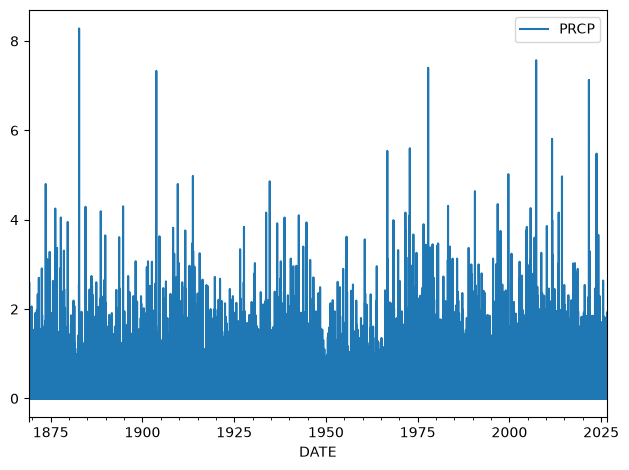

In [6]:
fig,ax=plt.subplots(layout='tight')
df.plot(ax=ax)
plt.show()

### If we wanted we could plot in centimeters
1 in = 2.54 cm.  

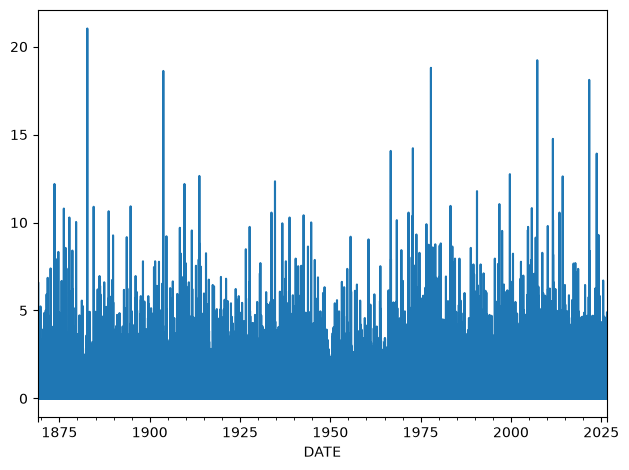

In [7]:
fig,ax=plt.subplots(layout='tight')
(df.PRCP*2.54/1).plot(ax=ax)  #we are doing the math and plotting at the same time!
plt.show()

### A few edits and we can show specific years

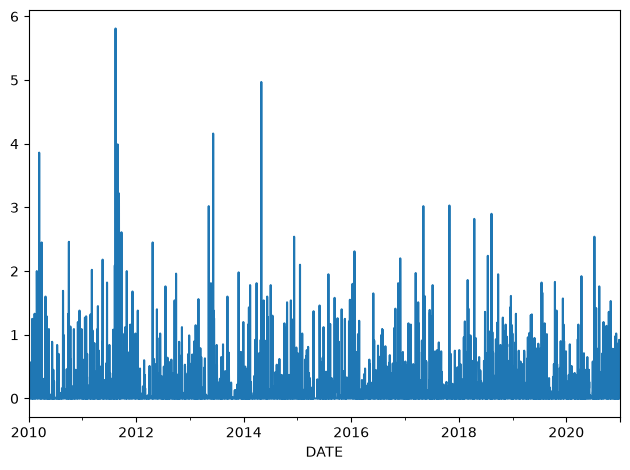

In [8]:
fig,ax=plt.subplots(layout='tight')
df.PRCP['2010':'2020'].plot(ax=ax)
plt.show()

### We can show just one year

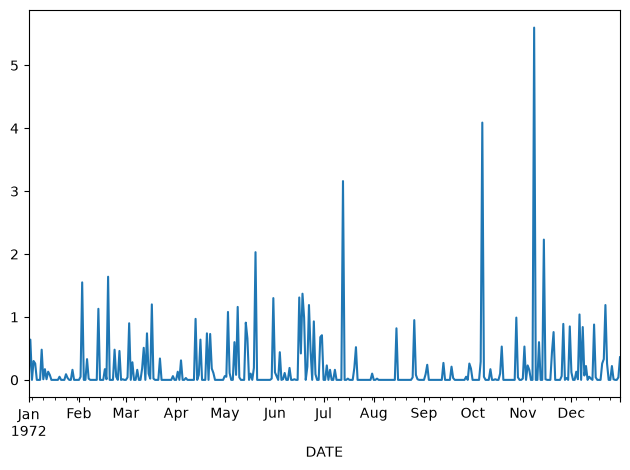

In [9]:
fig,ax=plt.subplots(layout='tight')
df.PRCP['1972'].plot(ax=ax)
plt.show()

### We can show just one month

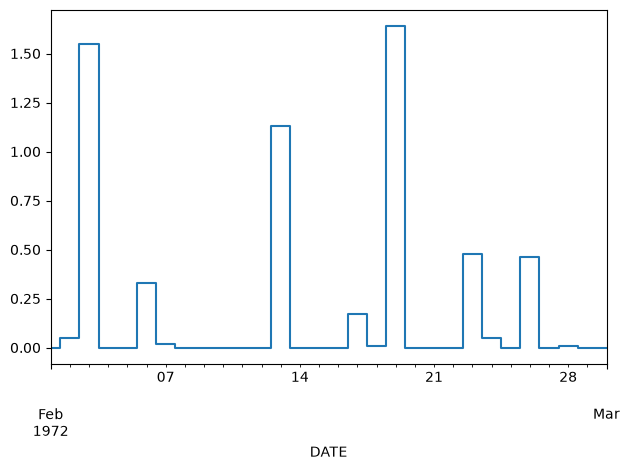

In [10]:
fig,ax=plt.subplots(layout='tight')


df.PRCP['02/01/1972':'03/01/1972'].plot(ax=ax, drawstyle="steps-mid")
plt.show()

## Annual Precipitation
- I want to know how much rain falls each year

In [11]:
df['PRCP'].resample('YE').sum()  #This just gave us yearly rainfall!

DATE
1869-12-31    45.25
1870-12-31    39.25
1871-12-31    51.38
1872-12-31    42.48
1873-12-31    47.99
              ...  
2022-12-31    46.30
2023-12-31    59.29
2024-12-31    46.37
2025-12-31    39.57
2026-12-31    25.85
Freq: YE-DEC, Name: PRCP, Length: 158, dtype: float64

### Now we could plot the yearly data!

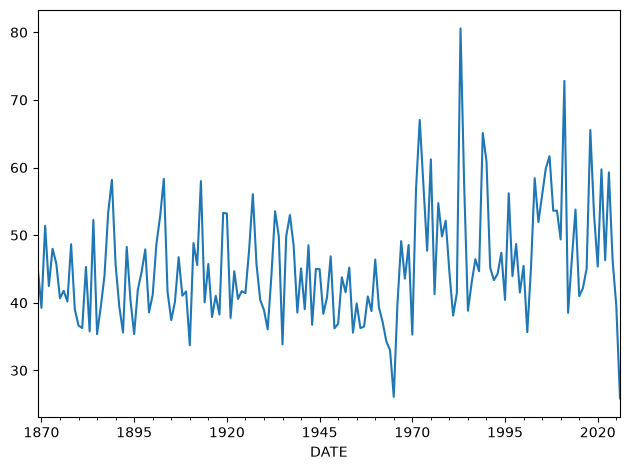

In [12]:
fig,ax=plt.subplots(layout='tight')
df['PRCP'].resample('YE').sum().plot(ax=ax)
plt.show()

### What type of plot?
-  We could also make it a scatter plot with points and no line.
-  This is the power of plotting with matplotlib. You can change anything!
-  go to https://matplotlib.org/1.3.1/examples/pylab_examples/filledmarker_demo.html
and choose your own color and style.
- To turn the line on and off.  Off you write 'none'.  Linestyl you can choose -, --, -., :

<Axes: xlabel='DATE'>

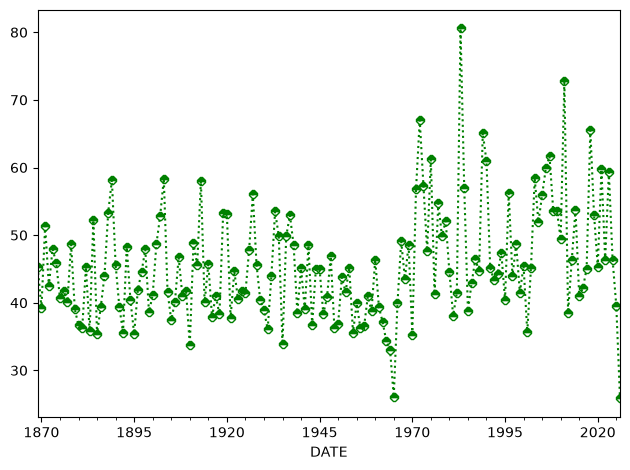

In [13]:
fig,ax=plt.subplots(layout='tight')
df['PRCP'].resample('YE').sum().plot(marker='8',color='g'
                                    ,fillstyle='top',linestyle=':'
                                   ,ax=ax)

### Do you see a trend or a change over time in precipiation?

Can you use describe to give statistics on the annual data? How much rain fell on the wettest year?

In [14]:
df['PRCP'].resample('YE').sum().describe()

count    158.000000
mean      45.470506
std        8.461469
min       25.850000
25%       39.465000
50%       44.605000
75%       49.307500
max       80.560000
Name: PRCP, dtype: float64

### We can compare before and after 1970

In [16]:
print('Before 1970\n',df['PRCP'][:'1970'].resample('YE').sum().describe())
print('\nAfter 1970\n',df['PRCP']['1970':].resample('YE').sum().describe())

Before 1970
 count    102.000000
mean      42.877745
std        6.218774
min       26.090000
25%       38.555000
50%       41.600000
75%       46.837500
max       58.320000
Name: PRCP, dtype: float64

After 1970
 count    57.000000
mean     49.931579
std      10.016277
min      25.850000
25%      43.350000
50%      47.390000
75%      56.770000
max      80.560000
Name: PRCP, dtype: float64


## Monthly Data
### My end point is to look at the monthly data in boxplots. 
- But to get there we need to resample to monthly. 
- Then we need to make a new column that lists the months. 
- Then we can make a boxplot!   

So lets start by making a new dataframe which is the data resampled by summing the monthly data. 



In [17]:
df_month=df.PRCP.resample('ME').sum().to_frame()

Now we can describe the data

In [18]:
df_month.describe()

,PRCP
count,1892.000000
mean,3.797220
std,2.134131
min,0.010000
25%,2.310000
50%,3.430000
75%,4.810000
max,18.950000


So things appear to be working.  What does our data look like?

In [19]:
df_month

,PRCP
DATE,
1869-01-31,2.53
1869-02-28,6.87
1869-03-31,4.61
1869-04-30,1.39
1869-05-31,4.15
...,...
2026-04-30,2.48
2026-05-31,3.05
2026-06-30,3.39


To make our plotting work we will need a new column that tells us just the month. So we are going to look at the index date and pull out the month and put it into a new column. 

In [20]:
df_month['month']=df_month.index.month

lets just look at 5 rows and see if it worked.  

In [21]:
df_month.head()  #head just gives you the first 5

,PRCP,month
DATE,,
1869-01-31,2.53,1
1869-02-28,6.87,2
1869-03-31,4.61,3
1869-04-30,1.39,4
1869-05-31,4.15,5


Now lets make our boxplot!  you can google pandas boxplot to see how.  http://pandas.pydata.org/pandas-docs/stable/visualization.html  


### Foreshadowing.  I am going to ask you to use this by notation in a future class!  
this is a big hint.  remember column and by.  I AM GOING TO ASK THIS AGAIN!

Also, to make it look fancy I am showing the mean values and making it have a notch.  You can make both options False or just delete them.  They are extra arguments in the function.

<Axes: title={'center': 'PRCP'}, xlabel='month'>

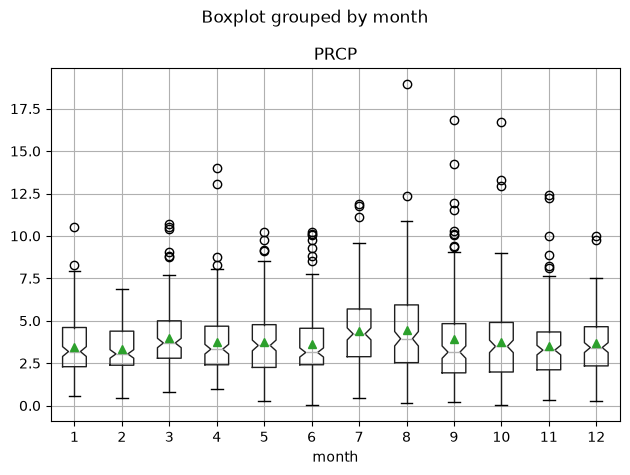

In [22]:
fig,ax=plt.subplots(layout='tight')
df_month.boxplot(column=['PRCP'],by='month'
                 ,showmeans=True,notch=True
                ,ax=ax)

## AI
- Now your first lesson in using AI.
- I want a better looking figure with all the data on it
- go to your gemini account.
    - Make a new chat
    - choose pro or thinking.  Flash can fail.
    - Paste in the script below.
    - Once it is done.  Copy the code and paste into colab and run it.  

Using the file 'https://raw.githubusercontent.com/bmaillou\
/BigDataPython/refs/heads/master/01-CentralPark/CentralPark2026.csv' I would like to make a boxplot of monthly precipitation
- Make a box plot of Monthly precitpaition
- Show the mean and remove outliers
- overlay a jittered scatter plot showing all the data for each month.  Have the scatter point in front of the boxplots.  
- color the points to see the before and after 1970 data
- label the x-axis with 3 letter month codes
- use fig,ax nomenclature and do not use seaborn

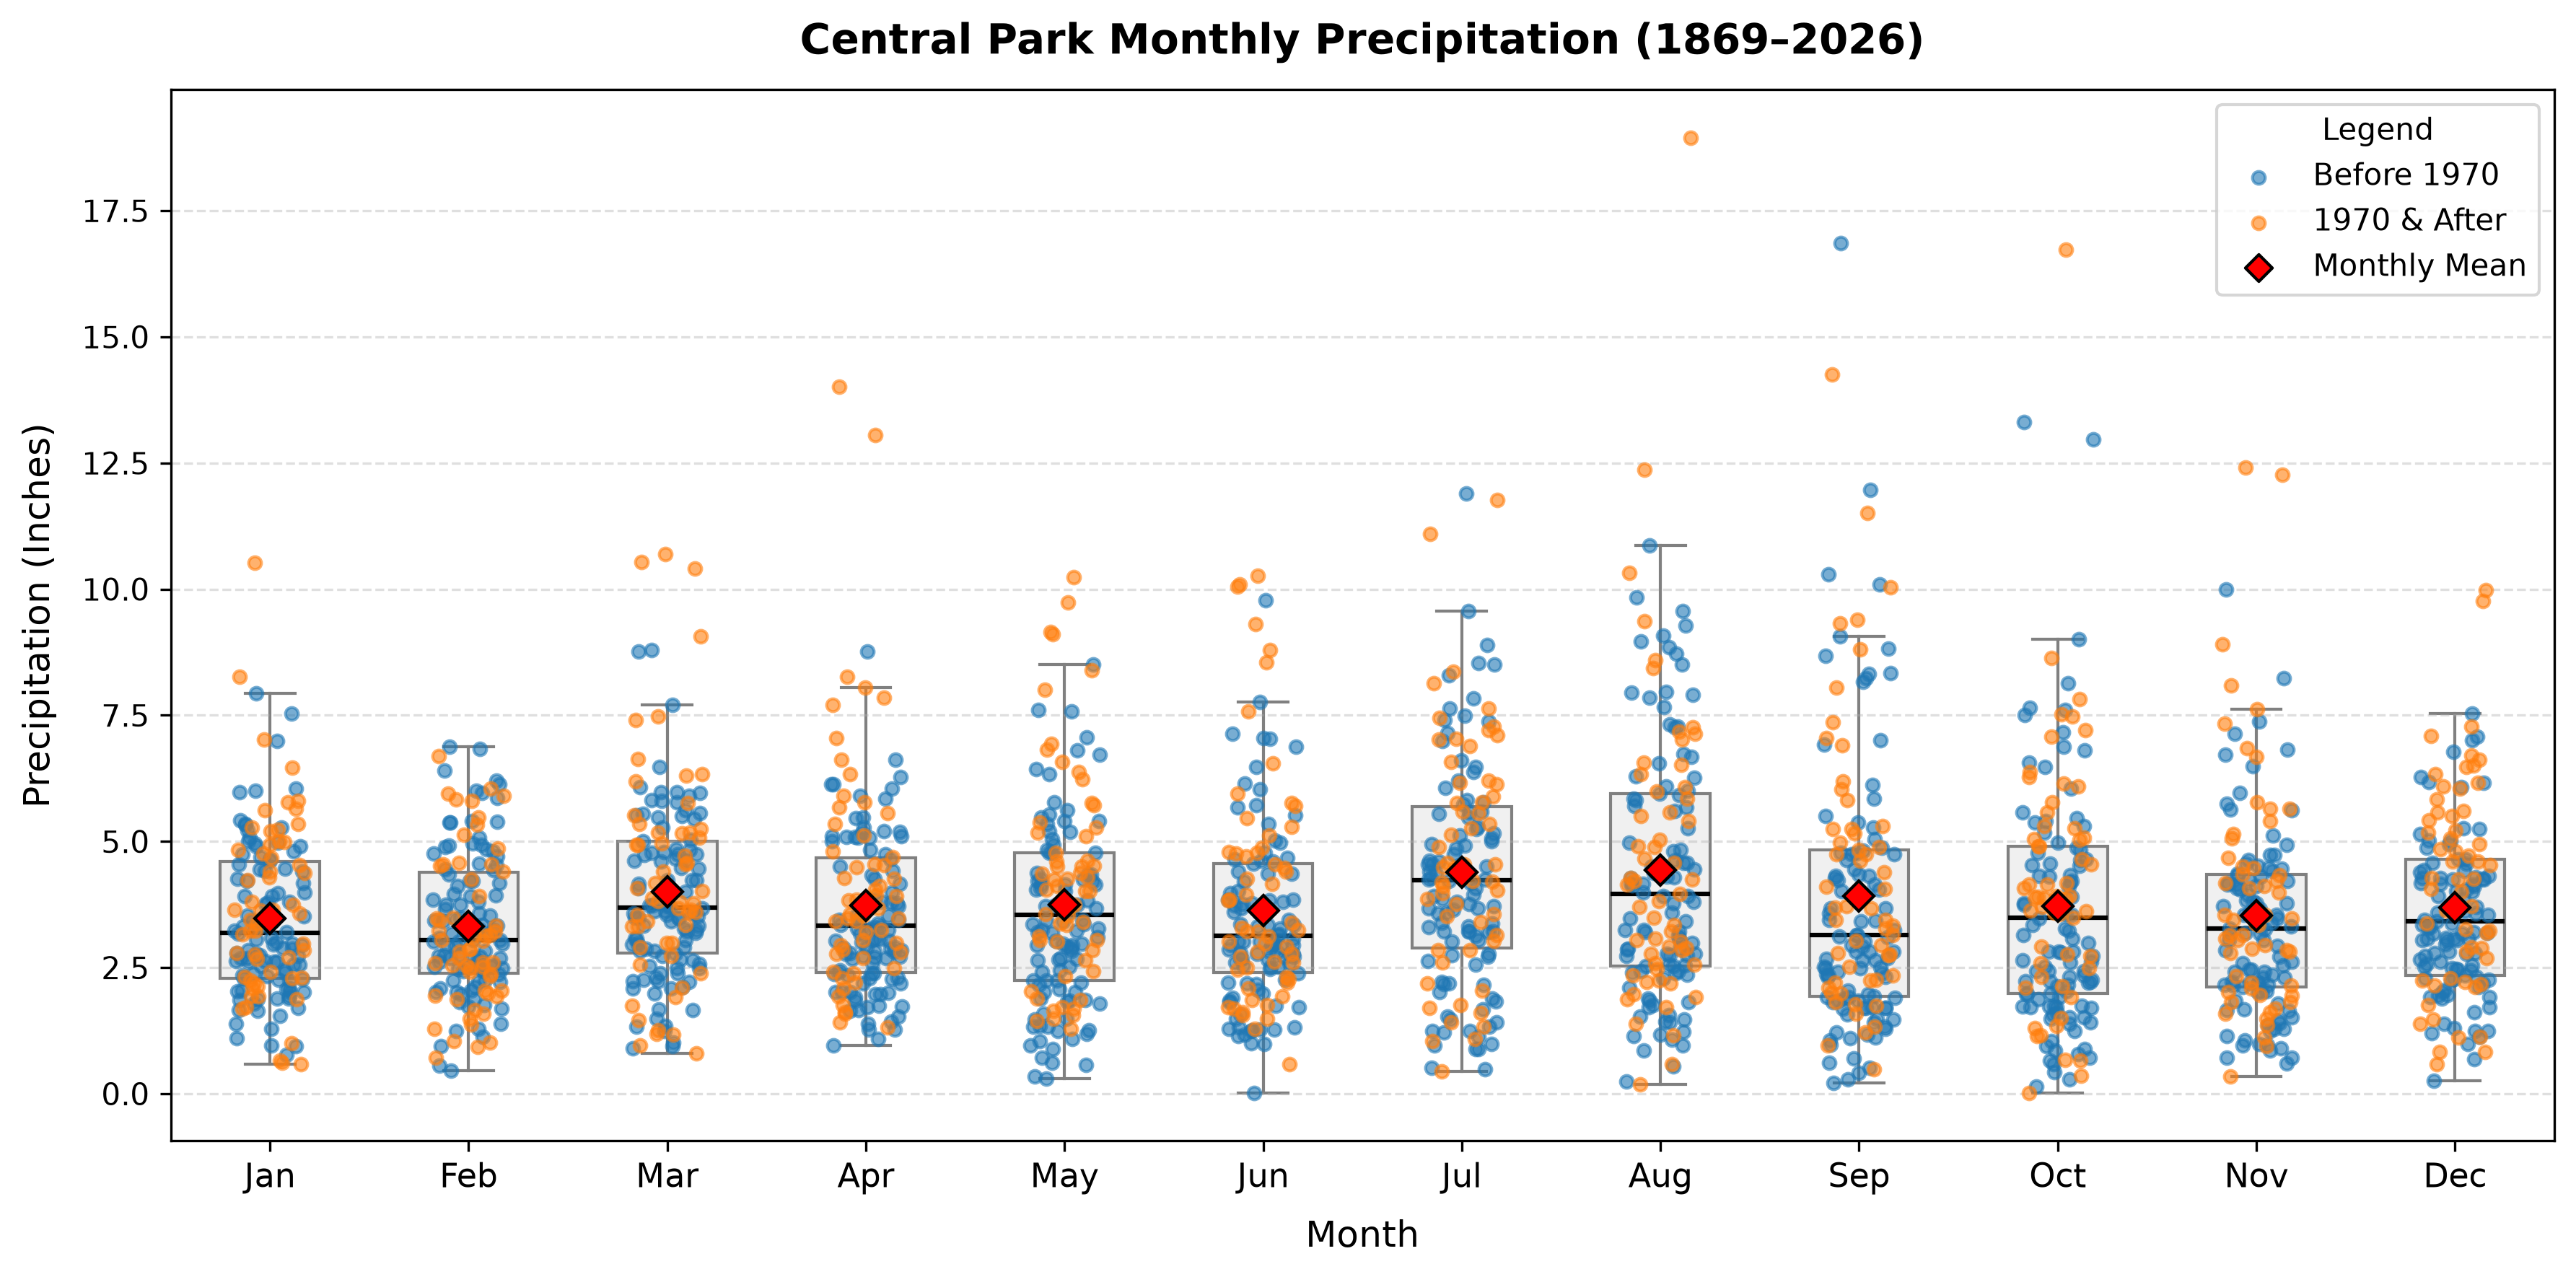

In [112]:
import calendar
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load data directly from GitHub URL
url = "https://raw.githubusercontent.com/bmaillou/BigDataPython/refs/heads/master/01-CentralPark/CentralPark2026.csv"
df = pd.read_csv(url)

# Convert DATE column to datetime
df["DATE"] = pd.to_datetime(df["DATE"])
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month

# 2. Calculate monthly total precipitation (excluding partial incomplete months)
monthly_df = df.groupby(["Year", "Month"])["PRCP"].sum().reset_index()

# Exclude incomplete final month (e.g., August 2026 if partial)
days_per_month = df.groupby(["Year", "Month"])["DATE"].count()
complete_months = days_per_month[days_per_month >= 28].index
monthly_df = monthly_df.set_index(["Year", "Month"]).loc[complete_months].reset_index()

# Separate pre-1970 and post-1970 subsets
pre_1970 = monthly_df[monthly_df["Year"] < 1970]
post_1970 = monthly_df[monthly_df["Year"] >= 1970]

# Extract data arrays for each month (1 through 12)
month_data = [
    monthly_df[monthly_df["Month"] == m]["PRCP"].values for m in range(1, 13)
]

# 3. Initialize plot using fig, ax nomenclature
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# 4. Draw boxplots (Remove outliers with showfliers=False, display mean with showmeans=True)
# Lower zorder ensures the boxplots render BEHIND the scatter points
ax.boxplot(
    month_data,
    positions=np.arange(1, 13),
    showfliers=False,  # Remove boxplot outlier points
    showmeans=True,  # Display the arithmetic mean
    meanprops=dict(
        marker="D",
        markeredgecolor="black",
        markerfacecolor="red",
        markersize=7,
        zorder=4,
    ),
    patch_artist=True,
    boxprops=dict(facecolor="#f0f0f0", color="gray", zorder=1),
    capprops=dict(color="gray", zorder=1),
    whiskerprops=dict(color="gray", zorder=1),
    medianprops=dict(color="black", linewidth=1.5, zorder=2),
)

# 5. Overlay jittered scatter plot IN FRONT of boxplots (zorder=3)
np.random.seed(42)  # For reproducible horizontal jitter

for m in range(1, 13):
    # Before 1970 points
    vals_pre = pre_1970[pre_1970["Month"] == m]["PRCP"]
    jitter_pre = np.random.uniform(-0.18, 0.18, size=len(vals_pre))
    ax.scatter(
        m + jitter_pre,
        vals_pre,
        color="#1f77b4",  # Blue
        alpha=0.6,
        s=18,
        zorder=3,  # Set in front of boxplots
        label="Before 1970" if m == 1 else "",
    )

    # 1970 & After points
    vals_post = post_1970[post_1970["Month"] == m]["PRCP"]
    jitter_post = np.random.uniform(-0.18, 0.18, size=len(vals_post))
    ax.scatter(
        m + jitter_post,
        vals_post,
        color="#ff7f0e",  # Orange
        alpha=0.6,
        s=18,
        zorder=3,  # Set in front of boxplots
        label="1970 & After" if m == 1 else "",
    )

# 6. Format X-axis with 3-letter month codes
month_codes = [calendar.month_abbr[i] for i in range(1, 13)]
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(month_codes, fontsize=11)

# Dummy point for mean in the legend
ax.scatter(
    [],
    [],
    color="red",
    marker="D",
    edgecolors="black",
    s=40,
    label="Monthly Mean",
)

# Title, Labels, Grid, and Legend
ax.set_title(
    "Central Park Monthly Precipitation (1869–2026)",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Month", fontsize=12, labelpad=8)
ax.set_ylabel("Precipitation (Inches)", fontsize=12, labelpad=8)
ax.grid(True, linestyle="--", alpha=0.4, axis="y", zorder=0)
ax.legend(title="Legend", loc="upper right", frameon=True)

fig.tight_layout()
plt.show()

I talk about making figure captions in the homework.  So lets make one here. Here is the definition of a [boxplot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.boxplot.html#:~:text=A%20box%20plot%20is%20a,the%20range%20of%20the%20data)

### Figure 1.  
Boxplot of monthly precipitation Central Park, New York City from 1876 to 2015.  The line is the median, the triangle is the mean, the box goes from Q1 to Q3 with the whiskers showing the range of the data.  Each data point is repreented by a scatter point colored by time periood and jiggered for ploting.   


### Extra time
I hope you got some of these to work and are excited about what we can do.  You just analyzed 50,000 precipitation data points on your first day!  We are ready to begin learning data analysis and Python! But for next class we have to go back to the basics!

If you have extra time you could ask gemini
- Do a t-test on the pre and post 1970 data.
- Determine the average number of days between each rainfall event in NYC
- Longest number of continous days with no rain
- Use your imagination

### Instructor code to clean up data before putting online.  
#### ignore

Can we read the file a csv file with dates from the 1800's to 2000's and fix them so they can stored as four digit years and easily read and plotted by pandas.
- read the file CentralPark2026Raw.csv
- Fix the Date column with four digit years from the 1800's, 1900's, and 2000's
- Save only the fixed dates and call DATE
- only keep the columns DATE, PRCP
- save to a file called CentralPark2026.csv

In [68]:
import pandas as pd

# 1. Read raw CSV
df = pd.read_csv('CentralPark2026Raw.csv')

# 2. Parse and format DATE to 4-digit ISO format (YYYY-MM-DD)
df['DATE'] = pd.to_datetime(df['DATE']).dt.strftime('%Y-%m-%d')

# 3. Filter only the required columns
columns_to_keep = ['DATE', 'PRCP']
df_clean = df[columns_to_keep]

# 4. Save to clean CSV
df_clean.to_csv('CentralPark2026.csv', index=False)

### new page
<div style="page-break-before: always;"></div>


# Exit Ticket
## Name:
## uni:

### Q1. In one or two sentences describe how precipiation in New York City at Central Park has changed over time.
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

### Q2.  How much precipiation fell in Central park on the exact day you were born.  